# Experiment No. 8
## Application of Optical Flow for Real-Time Object Tracking and Motion Analysis

### Aim

To implement an optical flow-based motion analysis system for real-time object tracking and evaluate its effectiveness in detecting and tracking moving objects in video sequences using Python and OpenCV.

## Theory

Optical Flow is used to estimate the motion of objects between consecutive video frames.

In this experiment, Shi-Tomasi Corner Detection is used to identify important feature points. The Lucas-Kanade Optical Flow algorithm tracks these feature points across consecutive frames.

Motion trajectories and displacement vectors are drawn to visualize the movement of the object.

Farneback Dense Optical Flow is also implemented to estimate motion over the image and compare its tracking performance with Lucas-Kanade Optical Flow.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
uploaded = files.upload()

video_path = next(iter(uploaded))

print("Video uploaded successfully:", video_path)


Saving vidssave.com bmw car#edit #for #car #lover #shorts #vira#video #menta#ma# 720P.mp4 to vidssave.com bmw car#edit #for #car #lover #shorts #vira#video #menta#ma# 720P.mp4
Video uploaded successfully: vidssave.com bmw car#edit #for #car #lover #shorts #vira#video #menta#ma# 720P.mp4


In [ ]:
cap = cv2.VideoCapture(video_path)

ret, old_frame = cap.read()

if not ret:
    print("Error: Could not read video")
else:
    print("Video loaded successfully!")

old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)


Video loaded successfully!


In [ ]:
feature_params = dict(
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

p0 = cv2.goodFeaturesToTrack(
    old_gray,
    mask=None,
    **feature_params
)

print("Feature points detected:", len(p0))

Feature points detected: 100


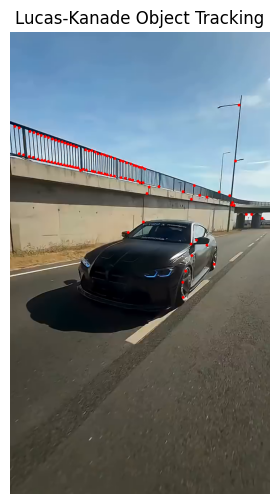

Tracked points: 100


In [ ]:
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(
        cv2.TERM_CRITERIA_EPS |
        cv2.TERM_CRITERIA_COUNT,
        10,
        0.03
    )
)

ret, frame = cap.read()

if ret:

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    p1, status, error = cv2.calcOpticalFlowPyrLK(
        old_gray,
        frame_gray,
        p0,
        None,
        **lk_params
    )

    good_new = p1[status == 1]
    good_old = p0[status == 1]

    output = frame.copy()

    for new, old in zip(good_new, good_old):

        x_new, y_new = new.ravel()
        x_old, y_old = old.ravel()

        cv2.arrowedLine(
            output,
            (int(x_old), int(y_old)),
            (int(x_new), int(y_new)),
            (0, 255, 0),
            2
        )

        cv2.circle(
            output,
            (int(x_new), int(y_new)),
            4,
            (0, 0, 255),
            -1
        )

    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title("Lucas-Kanade Object Tracking")
    plt.axis("off")
    plt.show()

    print("Tracked points:", len(good_new))

else:
    print("Could not read next frame.")

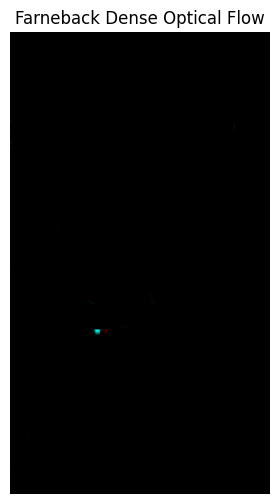

In [ ]:
# Convert first two frames to grayscale
cap2 = cv2.VideoCapture(video_path)

ret1, frame1 = cap2.read()
ret2, frame2 = cap2.read()

cap2.release()

gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

# Calculate Farneback Dense Optical Flow
flow = cv2.calcOpticalFlowFarneback(
    gray1,
    gray2,
    None,
    0.5,
    3,
    15,
    3,
    5,
    1.2,
    0
)

# Calculate magnitude and direction
magnitude, angle = cv2.cartToPolar(
    flow[..., 0],
    flow[..., 1]
)

# Create HSV visualization
hsv = np.zeros_like(frame1)

hsv[..., 1] = 255

hsv[..., 0] = angle * 180 / np.pi / 2

hsv[..., 2] = cv2.normalize(
    magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

dense_flow = cv2.cvtColor(
    hsv,
    cv2.COLOR_HSV2RGB
)

plt.figure(figsize=(12, 6))
plt.imshow(dense_flow)
plt.title("Farneback Dense Optical Flow")
plt.axis("off")
plt.show()


In [ ]:
average_magnitude = np.mean(magnitude)
maximum_magnitude = np.max(magnitude)

average_angle = np.mean(angle)

print("Motion Analysis")
print("----------------------------")
print("Average Motion Magnitude:", round(average_magnitude, 4))
print("Maximum Motion Magnitude:", round(maximum_magnitude, 4))
print("Average Motion Direction:", round(average_angle, 4), "radians")


Motion Analysis
----------------------------
Average Motion Magnitude: 0.0005
Maximum Motion Magnitude: 1.6172
Average Motion Direction: 3.2023 radians


In [ ]:
if len(good_new) > 0:

    displacement = np.linalg.norm(
        good_new - good_old,
        axis=1
    )

    average_displacement = np.mean(displacement)
    maximum_displacement = np.max(displacement)

    print("Object Motion Analysis")
    print("----------------------------")
    print(
        "Average Displacement:",
        round(average_displacement, 2),
        "pixels"
    )

    print(
        "Maximum Displacement:",
        round(maximum_displacement, 2),
        "pixels"
    )

else:
    print("No feature points were successfully tracked.")

Object Motion Analysis
----------------------------
Average Displacement: 0.0 pixels
Maximum Displacement: 0.0 pixels


## Comparison

| Feature | Lucas-Kanade | Farneback |
|---|---|---|
| Type | Sparse Optical Flow | Dense Optical Flow |
| Tracking | Selected feature points | Almost every pixel |
| Speed | Faster | Relatively slower |
| Computation | Lower | Higher |
| Motion Information | Feature points | Detailed image motion |
| Suitable For | Object tracking | Dense motion analysis |

## Applications

1. Traffic Monitoring
2. Autonomous Driving
3. Video Surveillance
4. Human Activity Recognition
5. Sports Analytics
6. Robotics
7. Object Tracking


## Observations

1. Shi-Tomasi Corner Detection successfully identifies important feature points.
2. Lucas-Kanade Optical Flow tracks the movement of selected feature points.
3. Motion vectors show the direction and displacement of moving points.
4. Farneback provides dense motion information over the image.
5. Fast-moving objects may reduce tracking accuracy.
6. Illumination changes and occlusion can affect tracking performance.
7. Camera movement can introduce additional motion into the optical flow.

## Conclusion

The optical flow-based object tracking system was successfully implemented using Python and OpenCV.

Shi-Tomasi Corner Detection was used to select feature points, and Lucas-Kanade Optical Flow was used to track their movement between consecutive frames. Farneback Dense Optical Flow was also implemented for detailed motion analysis.

The experiment demonstrated that optical flow can effectively estimate object displacement, trajectory, motion direction, and movement patterns. It can be applied in traffic monitoring, autonomous driving, surveillance, robotics, and human activity recognition.